# Modelo del Lenguaje
---

- Cada palabra en una secuencia esta representada por: $w_i$.
- Una cadena de texto: $[w_{i-k}, w_{i-k+1}, \dots, w_{i}]$.
- **Contexto**: conjunto de palabras previas $\{w_{i-k}, w_{i-k+1}, \dots, w_{i-1}\}$ a una palabra $w_i$.

    **Ejemplo**: La secuencia `este es un modelo del lenguaje`, para la palabra `"lenguaje"`, su contexto de tamano 3: `un modelo de`.
- **Token**: Minima unidad de procesamiento definida para la tarea en cuestion. Puede ser caracter, palabras, oraciones, sub-palabras (silabas, combinaciones de caracteres).
- **Vocabulario**: El conjunto de todos los posibles tokens en mi aplicacion.

    **Ejemplo**: Con tokens a nivel de caracter para una secuencia de ADN: `AACCATTTGACA` el vocabulario: `ATGC`
- **Corpus**: Conjunto de datos textuales que se usa para una aplicacion conctreta.

Un modelo del lenguaje se representa por la probabilidad conjunta:

$$
P(w_1, w_2, \dots, w_N)
$$

## Modelo de N-grams o Modelo de Markov Chain
---

Se asume indepedencia condicional para todas las palabras que se encuentren fuera del contexto de tamano $K$:

$$
P(w_i|w_{i-1}, w_{i-2}, \dots w_{i-k})
$$

## Corpus
---

Construir el conjunto de datos para entrenar un modelo del lenguaje.

In [1]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 24.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="24.04"
VERSION="24.04.4 LTS (Noble Numbat)"
VERSION_CODENAME=noble
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=noble
LOGO=ubuntu-logo


In [2]:
%%sh
echo "hello"

hello


In [3]:
import requests
from pathlib import Path

url = "https://raw.githubusercontent.com/BibleAquifer/ReinaValera1909/refs/heads/main/spa/md/{id}.content.md"
path = Path("data/")
path.mkdir(parents=True, exist_ok=True)

for i in range(1, 67):
    format_url = url.format(id=i if i >= 10 else f"0{i}")
    text = requests.get(format_url).text
    (path / f"{i}.md").write_text(text)
    print(f"{i}.md")

1.md
2.md
3.md
4.md
5.md
6.md
7.md
8.md
9.md
10.md
11.md
12.md
13.md
14.md
15.md
16.md
17.md
18.md
19.md
20.md
21.md
22.md
23.md
24.md
25.md
26.md
27.md
28.md
29.md
30.md
31.md
32.md
33.md
34.md
35.md
36.md
37.md
38.md
39.md
40.md
41.md
42.md
43.md
44.md
45.md
46.md
47.md
48.md
49.md
50.md
51.md
52.md
53.md
54.md
55.md
56.md
57.md
58.md
59.md
60.md
61.md
62.md
63.md
64.md
65.md
66.md


In [4]:
Path("data/1.md").read_text()[:1000]

'# Reina Valera 1909\n\n## License Information\n\n**Reina Valera 1909** is based on and adapted from: _Reina Valera 1909_, [Public Domain](https://creativecommons.org/public-domain/cc0/), 1909, which is licensed under a [Public Domain CC0](https://creativecommons.org/public-domain/cc0/).\n\nThis markdown version is provided under the same license.\n\n\n\n--------------------------------\n\n\n## Génesis 1:1 (id: 10001001001)\n\n1EN el principio crió Dios los cielos y la tierra.\n\n\n## Génesis 1:2 (id: 10001001002)\n\n2Y la tierra estaba desordenada y vacía, y las tinieblas estaban sobre la haz del abismo, y el Espíritu de Dios se movía sobre la haz de las aguas.\n\n\n## Génesis 1:3 (id: 10001001003)\n\n3Y dijo Dios: Sea la luz: y fué la luz.\n\n\n## Génesis 1:4 (id: 10001001004)\n\n4Y vió Dios que la luz era buena: y apartó Dios la luz de las tinieblas.\n\n\n## Génesis 1:5 (id: 10001001005)\n\n5Y llamó Dios á la luz Día, y á las tinieblas llamó Noche: y fué la tarde y la mañana un día.

## Pre-procesamiento
---

Consolidacion y limpieza de los datos.

In [5]:
def consolidate_corpus(path: Path) -> str:
    file_paths = path.glob("*.md")
    return "\n".join(map(lambda x: x.read_text().split("--------------------------------")[1], file_paths))

In [6]:
corpus = consolidate_corpus(Path("data/"))
len(corpus)

5027734

1. Tokenizacion a nivel de palabra considerando signos de puntacion.
2. Pasar todo a minusculas.
3. Eliminar caracteres especiales patrones innecesarios del texto (titulos, ids, entre otros).
4. Eliminar espacios duplicados y convertir saltos de linea a espacios.

In [7]:
import re
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
nltk.word_tokenize("El pan de Aser será grueso, y él dará deleites al rey.", language="spanish")

['El',
 'pan',
 'de',
 'Aser',
 'será',
 'grueso',
 ',',
 'y',
 'él',
 'dará',
 'deleites',
 'al',
 'rey',
 '.']

In [9]:
def preprocess(corpus: str) -> str:
    no_headers = re.sub(r"\n## [^\s]+ \d+:\d+ \(id: \d+\)\n", "", corpus)
    tokenized_text = " ".join(nltk.word_tokenize(no_headers, language="spanish"))
    lower_text = tokenized_text.lower()
    clean_text = re.sub(r"[^a-zà-ÿ\s,.:;]", " ", lower_text)
    return re.sub(r"\s+", " ", clean_text).strip()

In [10]:
print(corpus[:1000])




## 2 Crónicas 1:1 (id: 10014001001)

1Y SALOMÓN hijo de David fué afirmado en su reino; y Jehová su Dios fué con él, y le engrandeció sobremanera.


## 2 Crónicas 1:2 (id: 10014001002)

2Y llamó Salomón á todo Israel, tribunos, centuriones, y jueces, y á todos los príncipes de todo Israel, cabezas de familias.


## 2 Crónicas 1:3 (id: 10014001003)

3Y fué Salomón, y con él toda esta junta, al alto que había en Gabaón; porque allí estaba el tabernáculo del testimonio de Dios, que Moisés siervo de Jehová había hecho en el desierto.


## 2 Crónicas 1:4 (id: 10014001004)

4Mas David había traído el arca de Dios de Chîriath\-jearim al lugar que él le había preparado; porque él le había tendido una tienda en Jerusalem.


## 2 Crónicas 1:5 (id: 10014001005)

5Asimismo el altar de bronce que había hecho Bezaleel hijo de Uri hijo de Hur, estaba allí delante del tabernáculo de Jehová, al cual fué á consultar Salomón con aquella junta.


## 2 Crónicas 1:6 (id: 10014001006)

6Subió pues Salomón

In [11]:
display(preprocess(corpus[:1000]))

'crónicas : id : y salomón hijo de david fué afirmado en su reino ; y jehová su dios fué con él , y le engrandeció sobremanera . crónicas : id : y llamó salomón á todo israel , tribunos , centuriones , y jueces , y á todos los príncipes de todo israel , cabezas de familias . crónicas : id : y fué salomón , y con él toda esta junta , al alto que había en gabaón ; porque allí estaba el tabernáculo del testimonio de dios , que moisés siervo de jehová había hecho en el desierto . crónicas : id : mas david había traído el arca de dios de chîriath jearim al lugar que él le había preparado ; porque él le había tendido una tienda en jerusalem . crónicas : id : asimismo el altar de bronce que había hecho bezaleel hijo de uri hijo de hur , estaba allí delante del tabernáculo de jehová , al cual fué á consultar salomón con aquella junta . crónicas : id : subió pues salomón'

In [12]:
preprocess_corpus = preprocess(corpus)

## Modelo de N-grams

model:
- keys: context.
- values: palabras posibles de continuacion.

In [13]:
from collections import defaultdict

x = defaultdict(dict)
print(x)
print(x["uno"])

defaultdict(<class 'dict'>, {})
{}


In [14]:
x = defaultdict(lambda: defaultdict(int))
x["este es"]["el"]

0

In [15]:
from collections import defaultdict

def compute_ngrams(context_size: int, corpus: str) -> dict:
    model = defaultdict(lambda: defaultdict(int))
    tokens = corpus.split(" ")
    for i in range(len(tokens) - context_size):
        context = " ".join(tokens[i: i + context_size])
        model[context][tokens[i + context_size]] += 1

    probs = defaultdict(lambda: defaultdict(float))
    for context in model:
        total_count = sum(model[context].values())
        for token in model[context]:
            probs[context][token] = model[context][token] / total_count
    return probs

In [105]:
bigram = compute_ngrams(context_size=2, corpus=preprocess_corpus)
trigram = compute_ngrams(context_size=3, corpus=preprocess_corpus)
cuatrigram = compute_ngrams(context_size=4, corpus=preprocess_corpus)
fivegram = compute_ngrams(context_size=5, corpus=preprocess_corpus)

In [17]:
len(bigram)

192604

In [18]:
list(bigram.keys())[:5]

['crónicas :', ': id', 'id :', ': y', 'y salomón']

In [19]:
bigram["en el"]

defaultdict(float,
            {'desierto': 0.061241265926839296,
             'tabernáculo': 0.02260583641594739,
             'monte': 0.0448006576243321,
             'líbano': 0.005754212905877518,
             'lugar': 0.027127003699136867,
             'mes': 0.030415125359638306,
             'cuarto': 0.002877106452938759,
             'oratorio': 0.0008220304151253596,
             'templo': 0.034936292642827785,
             'arca': 0.009453349773941636,
             'corazón': 0.009042334566378957,
             'trono': 0.009453349773941636,
             'cielo': 0.02548294286888615,
             'pavimento': 0.0004110152075626798,
             'altar': 0.006165228113440197,
             'año': 0.03247020139745171,
             'hijo': 0.0032881216605014385,
             'camino': 0.03740238388820386,
             'quinto': 0.002055076037813399,
             'valle': 0.02178380600082203,
             'bosque': 0.002877106452938759,
             'torrente': 0.0020550760378133

In [20]:
sum(bigram["en el"].values())

1.0

## Autocompletado
---

In [21]:
def autocomplete(context: str, model: dict[str, dict[str, float]], n_options: int) -> list[str]:
    probs = model[context].items()
    return list(map(lambda i: i[0], sorted(probs, key=lambda x: x[1], reverse=True)[:n_options]))

In [22]:
autocomplete("en el", bigram, 5)

['desierto', 'día', 'monte', 'campo', 'camino']

In [23]:
autocomplete("en el desierto", trigram, 3)

[',', 'de', '.']

In [24]:
autocomplete("en el desierto ,", cuatrigram, 3)

['y', 'en', 'donde']

## Generacion de Texto

In [25]:
def generate_text(context: str, model: dict[str, dict[str, float]], context_size: int, n_words: int) -> str:
    generated_tokens = context.split(" ")
    for _ in range(n_words):
        probs = model[context].items()
        next_word = max(probs, key=lambda x: x[1])[0]
        generated_tokens.append(next_word)
        context = " ".join(generated_tokens[-context_size:])
    return " ".join(generated_tokens)

In [26]:
generate_text("en el", bigram, 2, 100)

'en el desierto , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad , y á los que se llamaba la ciudad'

In [27]:
generate_text("en el desierto", trigram, 3, 100)

'en el desierto , y el que se purifica , y sobre los moradores de jerusalem , y á los que estaban en la casa de jehová , y no se apagará . y esta es la ley de moisés , y á los que estaban en la casa de jehová , y no se apagará . y esta es la ley de moisés , y á los que estaban en la casa de jehová , y no se apagará . y esta es la ley de moisés , y á los que estaban en la casa de jehová , y no se'

In [28]:
generate_text("en el desierto ,", cuatrigram, 4, 100)

'en el desierto , y no verá cuando viniere el bien ; sino que morará en las securas en el desierto , y no verá cuando viniere el bien ; sino que morará en las securas en el desierto , y no verá cuando viniere el bien ; sino que morará en las securas en el desierto , y no verá cuando viniere el bien ; sino que morará en las securas en el desierto , y no verá cuando viniere el bien ; sino que morará en las securas en el desierto , y no verá cuando viniere el bien ; sino que'

In [29]:
import numpy as np

In [47]:
probs = {"word1": 0.3, "word2": 0.2, "word3": 0.5}
for _ in range(20):
    print(np.random.choice(list(probs.keys()), p=list(probs.values())))

word3
word3
word1
word1
word2
word3
word2
word1
word1
word1
word1
word3
word3
word2
word3
word3
word3
word3
word1
word1


In [48]:
def generate_text(context: str, model: dict[str, dict[str, float]], context_size: int, n_words: int) -> str:
    generated_tokens = context.split(" ")
    for _ in range(n_words):
        probs = model[context]
        next_word = str(np.random.choice(list(probs.keys()), p=list(probs.values())))
        generated_tokens.append(next_word)
        context = " ".join(generated_tokens[-context_size:])
    return " ".join(generated_tokens)

In [136]:
generate_text("en el", bigram, 2, 1000)

'en el desierto hasta el valle llamado de mí : porque el jordán . jehová hará mañana entre vosotros predicado , sois bienaventurados . por lo cual te ha dicho jehová ; y no viniere , tómalo de mí y entre los sacerdotes levitas que llevaban los siervos le dijeron : tu hija por mujer á la campiña . y si te parece que come , bebe tú también como sus barras , de los sabios en sus caminos , y sobre todos ellos ; y sabrán que yo mandaré acerca de mujeres : no hable el rey , que no les será perdonada á los de oriente los siros siete mil ; crónicas : id : los magistrados , ni por su fruto para sí las puertas : la vigésimaprima por jachim , la carne , y en sus moradas en el año del rey . y la sangre que estaba sentado sobre los egipcios muertos á cuchillo , y por tres días de jared , después que fué de los asirios , y como el montón de veinte mil batos . reyes : id : para que contra mí son todas las cosas que él estuvo allí en el segundo , zafiro ; el cual clamamos , abba , padre , y seamos sie

In [50]:
print(preprocess_corpus[:1000])

crónicas : id : y salomón hijo de david fué afirmado en su reino ; y jehová su dios fué con él , y le engrandeció sobremanera . crónicas : id : y llamó salomón á todo israel , tribunos , centuriones , y jueces , y á todos los príncipes de todo israel , cabezas de familias . crónicas : id : y fué salomón , y con él toda esta junta , al alto que había en gabaón ; porque allí estaba el tabernáculo del testimonio de dios , que moisés siervo de jehová había hecho en el desierto . crónicas : id : mas david había traído el arca de dios de chîriath jearim al lugar que él le había preparado ; porque él le había tendido una tienda en jerusalem . crónicas : id : asimismo el altar de bronce que había hecho bezaleel hijo de uri hijo de hur , estaba allí delante del tabernáculo de jehová , al cual fué á consultar salomón con aquella junta . crónicas : id : subió pues salomón allá delante de jehová , al altar de bronce que estaba en el tabernáculo del testimonio , y ofreció sobre él mil holocaustos .

In [51]:
all_tokens = preprocess_corpus.split(" ")

In [52]:
from collections import Counter

In [53]:
counts = Counter(all_tokens)

In [58]:
counts.most_common(50)

[(',', 63946),
 ('y', 48446),
 ('de', 44671),
 (':', 27957),
 ('.', 26455),
 ('que', 19817),
 ('á', 19324),
 ('la', 18739),
 ('el', 17443),
 ('los', 16584),
 ('en', 15783),
 (';', 11266),
 ('no', 8242),
 ('su', 7832),
 ('por', 6928),
 ('jehová', 6842),
 ('del', 6330),
 ('id', 6186),
 ('las', 5852),
 ('con', 5486),
 ('sus', 5312),
 ('para', 5056),
 ('se', 4822),
 ('porque', 4209),
 ('dios', 4122),
 ('al', 4031),
 ('él', 3943),
 ('tu', 3658),
 ('es', 3490),
 ('como', 3433),
 ('lo', 3420),
 ('mi', 3319),
 ('sobre', 3177),
 ('yo', 3091),
 ('tierra', 2934),
 ('hijos', 2829),
 ('mas', 2597),
 ('ellos', 2572),
 ('israel', 2562),
 ('rey', 2501),
 ('le', 2449),
 ('dijo', 2394),
 ('hijo', 2342),
 ('he', 2293),
 ('todos', 2265),
 ('te', 2227),
 ('todo', 2144),
 ('un', 2113),
 ('ha', 2055),
 ('me', 2009)]

In [59]:
counts.most_common()[-50:]

[('majados', 1),
 ('segaránse', 1),
 ('contenderán', 1),
 ('glotones', 1),
 ('examinará', 1),
 ('prolongará', 1),
 ('enriquecer', 1),
 ('apresúrase', 1),
 ('medrará', 1),
 ('esconderáse', 1),
 ('enlazan', 1),
 ('contendiere', 1),
 ('ría', 1),
 ('usurero', 1),
 ('aparcero', 1),
 ('agur', 1),
 ('jachê', 1),
 ('ucal', 1),
 ('rudo', 1),
 ('añadas', 1),
 ('manténme', 1),
 ('harte', 1),
 ('niegue', 1),
 ('blasfeme', 1),
 ('acuses', 1),
 ('sanguijuela', 1),
 ('saquen', 1),
 ('tráguenlo', 1),
 ('hartare', 1),
 ('heredare', 1),
 ('hormigas', 1),
 ('preparan', 1),
 ('acuadrilladas', 1),
 ('lebrel', 1),
 ('enalteciste', 1),
 ('pensaste', 1),
 ('exprime', 1),
 ('causará', 1),
 ('perviertan', 1),
 ('olvídense', 1),
 ('acuerden', 1),
 ('compróla', 1),
 ('apagó', 1),
 ('aplicó', 1),
 ('huso', 1),
 ('rueca', 1),
 ('tapices', 1),
 ('sobrepujaste', 1),
 ('ésa', 1),
 ('alábenla', 1)]

In [135]:
display(generate_text("en el desierto", trigram, 3, 900))

'en el desierto de la mar , é hizo reverencia . y alzando él sus ojos vió á benjamín su hermano , y colaborador nuestro en el evangelio de dios , diciendo : el reino de dios , y esté allí por testigo contra ti . bendito tú , oh jehová , tu misericordia , y que nació ciego : mas cómo vea ahora , no sabemos á dónde vas : cómo , pues , al sacerdote para ser limpio , será visto otra vez del sacerdote : y después que los tomaron á ellos , y los levantó todos los días de abías : é hirióle jehová , y sea sobre ti sangre . mas habido consejo , lo despidieron , diciendo : y tú , su hijo . reyes : id : y zachârías , jaaziel , semiramoth , jehiel , y con pasmo de corazón . no venga contra mí : ellos y sus ganados tomarán : sus cortinas , y todos los príncipes á jehudí hijo de nethanías , y johanán y jonathán hijos de carea , y todos los varones de anathoth , ciento veintiocho : jefe de los hijos de israel , porque aquellas habitaciones donde ha entrado el arca de dios está entre cortinas . samuel

In [134]:
generate_text(", que con peligro", cuatrigram, 4, 1000)

', que con peligro de sus vidas la han traído y no la quiso beber , sino derramóla á jehová , diciendo : hijo del hombre , he aquí que viene un mal . viene el fin , el fin viene sobre los cuatro cantones de la tierra . selah . ciertamente la ira del hombre te acarreará alabanza : tú reprimirás el resto de las iras . quién le denunciará en su cara su camino y de lo que él posee dará herencia á sus hijos ; para que lo sepa porque los caminos de jehová , y no ha sanado : dejadla , y vámonos cada uno á su casa . así fué humillado madián delante de los hijos de benjamín . de los hijos de ephraim , por sus contados , treinta y dos mil y setecientos . junto á él acamparán los de la tribu de benjamín , ciento y ochenta días . y cumplidos estos días , hizo el rey banquete por siete días en el patio del huerto del palacio al aposento del banquete del vino en su furor , y fuego los consumirá . su fruto destruirás de la tierra , hasta llegar á gaza . samuel : id : y bacbaccar , heres , y galal , y

## Temperatura

$$
P(x_i) = \frac{e^{-x_i/T}}{\sum_{k}e^{-x_k/T}}
$$

In [137]:
words = {"perro": 10, "gato": 3, "pajaro": 5}

In [139]:
import matplotlib.pyplot as plt

<BarContainer object of 3 artists>

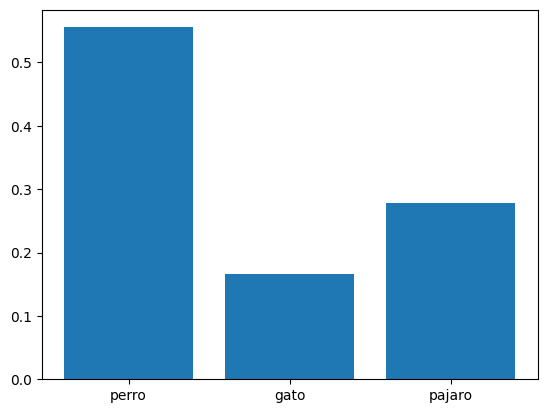

In [142]:
fig, ax = plt.subplots()
counts = np.array(list(words.values()))
probs = counts / counts.sum()
ax.bar(words.keys(), probs)

In [151]:
def boltzman(counts, temperature: float):
    exps = np.exp(counts / temperature)
    print(exps)
    return exps / exps.sum()

[1.10517092 1.03045453 1.0512711 ]


<BarContainer object of 3 artists>

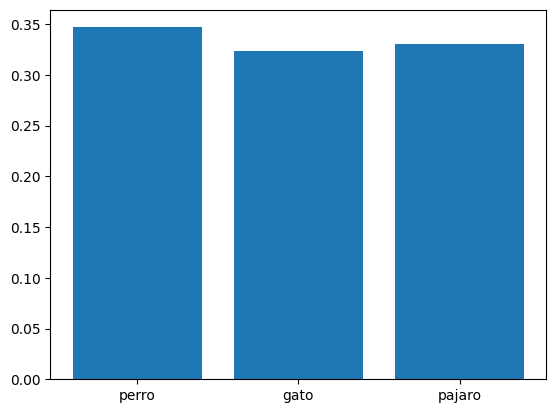

In [156]:
fig, ax = plt.subplots()
counts = np.array(list(words.values())).astype("float")
probs = boltzman(counts, 100)
ax.bar(words.keys(), probs)